# Day 18 — Market Basket Analysis

## Objective

Identify products that frequently occur together in customer transactions and
use association rules to recommend bundles and cross-sell opportunities.

## Dataset

This analysis uses the real UCI Online Retail transaction dataset introduced in
Day 17:

`data/online_retail/Online Retail.xlsx`

The project Titanic dataset is not appropriate for market basket analysis because
it contains passenger-level records rather than transaction-level product baskets.

## Analysis Plan

1. Validate the transaction data.
2. Shape invoice-level product baskets.
3. Mine frequent itemsets using the Apriori algorithm.
4. Generate association rules using support, confidence and lift.
5. Filter for high-support, high-lift and actionable rules.
6. Interpret the strongest rules in business terms.
7. Recommend product bundles and cross-sell opportunities.
8. Check basket-size and seasonal effects before finalising recommendations.

## Key Metrics

- **Support:** proportion of baskets containing an itemset.
- **Confidence:** probability of the consequent appearing given the antecedent.
- **Lift:** strength of association relative to the products occurring independently.

## Important Limitation

Association rules describe co-occurrence patterns in transaction data. They do
not prove that purchasing one product causes a customer to purchase another.
Results may also vary with basket size, seasonality and the time period analysed.

In [1]:
import pandas as pd
import numpy as np

# Load the real Online Retail transaction dataset
retail_df = pd.read_excel("data/online_retail/Online Retail.xlsx")

print("Dataset shape:", retail_df.shape)

print("\nColumns:")
print(retail_df.columns.tolist())

print("\nDate range:")
print("First transaction:", retail_df["InvoiceDate"].min())
print("Last transaction:", retail_df["InvoiceDate"].max())

print("\nUnique invoices:", retail_df["InvoiceNo"].nunique())
print("Unique products:", retail_df["StockCode"].nunique())
print("Unique customers:", retail_df["CustomerID"].nunique())

print("\nMissing values:")
print(retail_df.isna().sum())

Dataset shape: (541909, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Date range:
First transaction: 2010-12-01 08:26:00
Last transaction: 2011-12-09 12:50:00

Unique invoices: 25900
Unique products: 4070
Unique customers: 4372

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [2]:
# Day 18 — Validate data for market basket analysis

print("Raw dataset shape:", retail_df.shape)

# Identify cancellations
is_cancellation = retail_df["InvoiceNo"].astype(str).str.startswith("C")

print("\nCancellation rows:", is_cancellation.sum())
print("Negative quantity rows:", (retail_df["Quantity"] < 0).sum())
print("Zero quantity rows:", (retail_df["Quantity"] == 0).sum())
print("Non-positive UnitPrice rows:", (retail_df["UnitPrice"] <= 0).sum())
print("Missing descriptions:", retail_df["Description"].isna().sum())

# Product-code and invoice-level uniqueness
print("\nUnique invoices:", retail_df["InvoiceNo"].nunique())
print("Unique stock codes:", retail_df["StockCode"].nunique())

print("\nCountry count:", retail_df["Country"].nunique())
print("\nTop 10 countries:")
print(retail_df["Country"].value_counts().head(10))

Raw dataset shape: (541909, 8)

Cancellation rows: 9288
Negative quantity rows: 10624
Zero quantity rows: 0
Non-positive UnitPrice rows: 2517
Missing descriptions: 1454

Unique invoices: 25900
Unique stock codes: 4070

Country count: 38

Top 10 countries:
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64


In [3]:
# Build a clean purchase-level dataset

basket_df = retail_df.copy()

basket_df["is_cancellation"] = (
    basket_df["InvoiceNo"].astype(str).str.startswith("C")
)

basket_df = basket_df[
    (~basket_df["is_cancellation"])
    & (basket_df["Quantity"] > 0)
    & (basket_df["UnitPrice"] > 0)
    & (basket_df["StockCode"].notna())
    & (basket_df["Description"].notna())
].copy()

# Normalise product descriptions
basket_df["Description"] = (
    basket_df["Description"]
    .str.strip()
    .str.upper()
)

print("Original rows:", len(retail_df))
print("Clean purchase rows:", len(basket_df))
print("Rows removed:", len(retail_df) - len(basket_df))

print("\nUnique purchase invoices:", basket_df["InvoiceNo"].nunique())
print("Unique products:", basket_df["StockCode"].nunique())

print("\nRemaining cancellations:",
      basket_df["is_cancellation"].sum())

print("Remaining invalid quantities:",
      (basket_df["Quantity"] <= 0).sum())

print("Remaining invalid prices:",
      (basket_df["UnitPrice"] <= 0).sum())

print("Remaining missing descriptions:",
      basket_df["Description"].isna().sum())

Original rows: 541909
Clean purchase rows: 530104
Rows removed: 11805

Unique purchase invoices: 19960
Unique products: 3922

Remaining cancellations: 0
Remaining invalid quantities: 0
Remaining invalid prices: 0
Remaining missing descriptions: 0


In [4]:
# Calculate the number of distinct products per invoice

basket_sizes = (
    basket_df.groupby("InvoiceNo")["StockCode"]
    .nunique()
)

print("Number of baskets:", len(basket_sizes))

print("\nBasket-size summary:")
print(basket_sizes.describe().round(2))

print("\nSelected basket-size percentiles:")
print(
    basket_sizes.quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    ).round(2)
)

print("\nLargest basket size:", basket_sizes.max())

Number of baskets: 19960

Basket-size summary:
count    19960.00
mean        26.03
std         46.98
min          1.00
25%          6.00
50%         15.00
75%         29.00
max       1110.00
Name: StockCode, dtype: float64

Selected basket-size percentiles:
0.25      6.00
0.50     15.00
0.75     29.00
0.90     52.00
0.95     75.00
0.99    217.41
Name: StockCode, dtype: float64

Largest basket size: 1110


In [5]:
# Create invoice x product basket matrix

basket_matrix = (
    basket_df
    .groupby(["InvoiceNo", "Description"])["Quantity"]
    .sum()
    .unstack(fill_value=0)
)

# Convert quantities to binary presence/absence
basket_matrix = (basket_matrix > 0).astype(int)

print("Basket matrix shape:", basket_matrix.shape)

print("\nNumber of baskets:", basket_matrix.shape[0])
print("Number of products:", basket_matrix.shape[1])

print("\nTotal item-presence records:",
      int(basket_matrix.to_numpy().sum()))

Basket matrix shape: (19960, 4015)

Number of baskets: 19960
Number of products: 4015

Total item-presence records: 519309


In [6]:
# Most frequently purchased products by basket count

product_support = (
    basket_matrix.mean()
    .sort_values(ascending=False)
)

top_products = pd.DataFrame({
    "Product": product_support.head(20).index,
    "Basket_Count": (
        product_support.head(20)
        * len(basket_matrix)
    ).round().astype(int).values,
    "Support_%": (
        product_support.head(20) * 100
    ).round(2).values
})

display(top_products)

,Product,Basket_Count,Support_%
0,WHITE HANGING HEART T-LIGHT HOLDER,2256,11.30
1,JUMBO BAG RED RETROSPOT,2089,10.47
2,REGENCY CAKESTAND 3 TIER,1988,9.96
3,PARTY BUNTING,1685,8.44
4,LUNCH BAG RED RETROSPOT,1564,7.84
5,ASSORTED COLOUR BIRD ORNAMENT,1455,7.29
6,SET OF 3 CAKE TINS PANTRY DESIGN,1385,6.94
7,PACK OF 72 RETROSPOT CAKE CASES,1320,6.61
8,LUNCH BAG BLACK SKULL.,1273,6.38
9,NATURAL SLATE HEART CHALKBOARD,1249,6.26


In [7]:
from mlxtend.frequent_patterns import apriori

# Mine frequent itemsets
frequent_itemsets = apriori(
    basket_matrix,
    min_support=0.02,
    use_colnames=True,
    max_len=3
)

frequent_itemsets["itemset_size"] = (
    frequent_itemsets["itemsets"].apply(len)
)

frequent_itemsets = frequent_itemsets.sort_values(
    ["itemset_size", "support"],
    ascending=[True, False]
).reset_index(drop=True)

print("Frequent itemsets found:", len(frequent_itemsets))

print("\nItemset-size distribution:")
print(frequent_itemsets["itemset_size"].value_counts().sort_index())

print("\nTop frequent itemsets:")
display(
    frequent_itemsets.head(20)
)

/Users/nithinns/placemux-day1/env/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Frequent itemsets found: 379

Itemset-size distribution:
itemset_size
1    297
2     79
3      3
Name: count, dtype: int64

Top frequent itemsets:


,support,itemsets,itemset_size
0,0.113026,frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),1
1,0.104659,frozenset({JUMBO BAG RED RETROSPOT}),1
2,0.099599,frozenset({REGENCY CAKESTAND 3 TIER}),1
3,0.084419,frozenset({PARTY BUNTING}),1
4,0.078357,frozenset({LUNCH BAG RED RETROSPOT}),1
5,0.072896,frozenset({ASSORTED COLOUR BIRD ORNAMENT}),1
6,0.069389,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN}),1
7,0.066132,frozenset({PACK OF 72 RETROSPOT CAKE CASES}),1
8,0.063778,frozenset({LUNCH BAG BLACK SKULL.}),1
9,0.062575,frozenset({NATURAL SLATE HEART CHALKBOARD}),1


In [8]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0
)

print("Total association rules:", len(rules))

print("\nRule columns:")
print(rules.columns.tolist())

print("\nRules with lift > 1:")
print((rules["lift"] > 1).sum())

Total association rules: 176

Rule columns:
['antecedents', 'consequents', 'antecedent support', 'consequent support', 'support', 'confidence', 'lift', 'representativity', 'leverage', 'conviction', 'zhangs_metric', 'jaccard', 'certainty', 'kulczynski']

Rules with lift > 1:
176


In [9]:
# Convert frozensets into readable product names

def format_itemset(itemset):
    return ", ".join(sorted(itemset))

rules["antecedent"] = rules["antecedents"].apply(format_itemset)
rules["consequent"] = rules["consequents"].apply(format_itemset)

rules["support_pct"] = rules["support"] * 100
rules["confidence_pct"] = rules["confidence"] * 100

# Keep useful columns
rules_readable = rules[
    [
        "antecedent",
        "consequent",
        "support",
        "support_pct",
        "confidence",
        "confidence_pct",
        "lift"
    ]
].copy()

print("Readable rules created:", len(rules_readable))

display(
    rules_readable.sort_values(
        ["lift", "support"],
        ascending=[False, False]
    ).head(20)
)

Readable rules created: 176


,antecedent,consequent,support,support_pct,confidence,confidence_pct,lift
160,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.027104,2.710421,0.705346,70.534550,18.403524
161,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.027104,2.710421,0.707190,70.718954,18.403524
158,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.027104,2.710421,0.904682,90.468227,17.825724
163,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",0.027104,2.710421,0.534057,53.405726,17.825724
12,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.031663,3.166333,0.826144,82.614379,16.278213
13,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.031663,3.166333,0.623889,62.388944,16.278213
159,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,0.027104,2.710421,0.856013,85.601266,16.043204
162,ROSES REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",0.027104,2.710421,0.507981,50.798122,16.043204
30,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.027355,2.735471,0.720317,72.031662,15.747557
31,GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,0.027355,2.735471,0.598028,59.802848,15.747557


In [10]:
# Filter to more actionable association rules

MIN_SUPPORT = 0.02
MIN_LIFT = 1.20
MIN_CONFIDENCE = 0.30

vetted_rules = rules_readable[
    (rules_readable["support"] >= MIN_SUPPORT)
    & (rules_readable["lift"] >= MIN_LIFT)
    & (rules_readable["confidence"] >= MIN_CONFIDENCE)
].copy()

# Prioritise rules using lift and support
vetted_rules["priority_score"] = (
    vetted_rules["lift"]
    * vetted_rules["support"]
)

vetted_rules = vetted_rules.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

print("Total rules:", len(rules_readable))
print("Vetted actionable rules:", len(vetted_rules))

print("\nVetted rule summary:")
display(
    vetted_rules.head(20)
)

Total rules: 176
Vetted actionable rules: 151

Vetted rule summary:


,antecedent,consequent,support,support_pct,confidence,confidence_pct,lift,priority_score
0,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.038427,3.842685,0.720188,72.018779,14.190472,0.545295
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.038427,3.842685,0.757157,75.715696,14.190472,0.545295
2,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.031663,3.166333,0.826144,82.614379,16.278213,0.515422
3,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.031663,3.166333,0.623889,62.388944,16.278213,0.515422
4,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.027104,2.710421,0.705346,70.534550,18.403524,0.498813
5,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.027104,2.710421,0.707190,70.718954,18.403524,0.498813
6,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",0.027104,2.710421,0.534057,53.405726,17.825724,0.483152
7,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.027104,2.710421,0.904682,90.468227,17.825724,0.483152
8,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.029960,2.995992,0.781699,78.169935,14.650440,0.438926
9,ROSES REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.029960,2.995992,0.561502,56.150235,14.650440,0.438926


In [26]:
# Final business-focused rule selection
# Rebuild directly from the original `rules` DataFrame so the
# antecedents/consequents remain proper itemsets.

business_rules = rules.copy()

# Apply the same vetting thresholds
business_rules = business_rules[
    (business_rules["support"] >= MIN_SUPPORT)
    & (business_rules["lift"] >= MIN_LIFT)
    & (business_rules["confidence"] >= MIN_CONFIDENCE)
].copy()

# Keep only true 1-item -> 1-item rules
business_rules = business_rules[
    (business_rules["antecedents"].apply(len) == 1)
    & (business_rules["consequents"].apply(len) == 1)
].copy()

# Remove any accidental self-associations
business_rules = business_rules[
    business_rules.apply(
        lambda row: not bool(
            row["antecedents"] & row["consequents"]
        ),
        axis=1
    )
].copy()

# Extract the actual single product from each side
business_rules["Item_A"] = business_rules["antecedents"].apply(
    lambda x: next(iter(x))
)

business_rules["Item_B"] = business_rules["consequents"].apply(
    lambda x: next(iter(x))
)

# Create an unordered pair key so A -> B and B -> A
# are treated as the same underlying product relationship
business_rules["pair_key"] = business_rules.apply(
    lambda row: tuple(
        sorted([row["Item_A"], row["Item_B"]])
    ),
    axis=1
)

# Keep the strongest direction for each unique product pair
business_rules = (
    business_rules
    .sort_values(
        ["lift", "support", "confidence"],
        ascending=[False, False, False]
    )
    .drop_duplicates("pair_key")
    .copy()
)

# Business priority: association strength weighted by frequency
business_rules["priority_score"] = (
    business_rules["support"] * business_rules["lift"]
)

business_rules = (
    business_rules
    .sort_values(
        ["priority_score", "lift", "support"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

# Final top 10
top_business_rules = business_rules.head(10).copy()

# Human-readable metrics
top_business_rules["support_pct"] = (
    top_business_rules["support"] * 100
)

top_business_rules["confidence_pct"] = (
    top_business_rules["confidence"] * 100
)

# Practical recommendation
top_business_rules["Business_Recommendation"] = (
    top_business_rules.apply(
        lambda row:
        f"Test {row['Item_B']} as a cross-sell recommendation "
        f"when a customer views or buys {row['Item_A']}. "
        f"Consider a bundle or paired placement if the "
        f"relationship remains consistent.",
        axis=1
    )
)

# Check concentration in the Regency product family
top_business_rules["Regency_Family_Rule"] = (
    top_business_rules.apply(
        lambda row:
        "REGENCY" in (
            row["Item_A"] + " " + row["Item_B"]
        ).upper(),
        axis=1
    )
)

regency_count = (
    top_business_rules["Regency_Family_Rule"].sum()
)

print("Original association rules:", len(rules))
print("Vetted rules using thresholds:", len(business_rules))
print("Unique 1-to-1 business rules:", len(business_rules))

print("\nFinal rules reported:", len(top_business_rules))
print("Rules involving 'REGENCY':", regency_count)

print(
    "Regency-rule share:",
    round(
        regency_count / len(top_business_rules) * 100,
        2
    ),
    "%"
)

print("\nFinal business-focused association rules:")

display(
    top_business_rules[
        [
            "Item_A",
            "Item_B",
            "support_pct",
            "confidence_pct",
            "lift",
            "priority_score",
            "Business_Recommendation"
        ]
    ].round({
        "support_pct": 2,
        "confidence_pct": 2,
        "lift": 2,
        "priority_score": 4
    })
)

Original association rules: 176
Vetted rules using thresholds: 78
Unique 1-to-1 business rules: 78

Final rules reported: 10
Rules involving 'REGENCY': 3
Regency-rule share: 30.0 %

Final business-focused association rules:


,Item_A,Item_B,support_pct,confidence_pct,lift,priority_score,Business_Recommendation
0,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,3.84,72.02,14.19,0.5453,Test GREEN REGENCY TEACUP AND SAUCER as a cros...
1,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,3.17,82.61,16.28,0.5154,Test GREEN REGENCY TEACUP AND SAUCER as a cros...
2,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,3.00,78.17,14.65,0.4389,Test ROSES REGENCY TEACUP AND SAUCER as a cros...
3,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,2.74,72.03,15.75,0.4308,Test GARDENERS KNEELING PAD KEEP CALM as a cro...
4,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,3.21,65.31,12.40,0.3977,Test ALARM CLOCK BAKELIKE RED as a cross-sell ...
5,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,2.70,63.29,14.04,0.3784,Test SPACEBOY LUNCH BOX as a cross-sell recomm...
6,RED RETROSPOT CHARLOTTE BAG,CHARLOTTE BAG PINK POLKADOT,2.62,50.58,13.61,0.3558,Test CHARLOTTE BAG PINK POLKADOT as a cross-se...
7,PAPER CHAIN KIT VINTAGE CHRISTMAS,PAPER CHAIN KIT 50'S CHRISTMAS,2.77,67.32,11.58,0.3203,Test PAPER CHAIN KIT 50'S CHRISTMAS as a cross...
8,STRAWBERRY CHARLOTTE BAG,RED RETROSPOT CHARLOTTE BAG,2.43,67.31,13.02,0.3170,Test RED RETROSPOT CHARLOTTE BAG as a cross-se...
9,WOODLAND CHARLOTTE BAG,RED RETROSPOT CHARLOTTE BAG,2.53,60.62,11.73,0.2967,Test RED RETROSPOT CHARLOTTE BAG as a cross-se...


In [11]:
# Remove self-referential rules and duplicate directional pairs

def has_overlap(row):
    antecedent_items = set(
        item.strip() for item in row["antecedent"].split(",")
    )
    consequent_items = set(
        item.strip() for item in row["consequent"].split(",")
    )
    return bool(antecedent_items & consequent_items)


vetted_rules = vetted_rules[
    ~vetted_rules.apply(has_overlap, axis=1)
].copy()

print("Rules after overlap removal:", len(vetted_rules))

display(
    vetted_rules[
        [
            "antecedent",
            "consequent",
            "support_pct",
            "confidence_pct",
            "lift",
            "priority_score"
        ]
    ].head(15)
)

Rules after overlap removal: 151


,antecedent,consequent,support_pct,confidence_pct,lift,priority_score
0,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,3.842685,72.018779,14.190472,0.545295
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,3.842685,75.715696,14.190472,0.545295
2,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,3.166333,82.614379,16.278213,0.515422
3,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,3.166333,62.388944,16.278213,0.515422
4,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,2.710421,70.534550,18.403524,0.498813
5,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",2.710421,70.718954,18.403524,0.498813
6,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",2.710421,53.405726,17.825724,0.483152
7,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,2.710421,90.468227,17.825724,0.483152
8,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,2.995992,78.169935,14.650440,0.438926
9,ROSES REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,2.995992,56.150235,14.650440,0.438926


In [12]:
# Add a business interpretation for each vetted rule

def interpret_rule(row):
    return (
        f"Customers buying [{row['antecedent']}] also tend to buy "
        f"[{row['consequent']}]. The rule appears in "
        f"{row['support_pct']:.2f}% of baskets, has "
        f"{row['confidence_pct']:.2f}% confidence and a lift of "
        f"{row['lift']:.2f}."
    )


top_rules = vetted_rules.head(10).copy()

top_rules["Business_Interpretation"] = (
    top_rules.apply(interpret_rule, axis=1)
)

top_rules["Recommendation"] = (
    "Test this association as a cross-sell placement, "
    "bundle or recommendation pairing."
)

display(
    top_rules[
        [
            "antecedent",
            "consequent",
            "support_pct",
            "confidence_pct",
            "lift",
            "Business_Interpretation",
            "Recommendation"
        ]
    ]
)

,antecedent,consequent,support_pct,confidence_pct,lift,Business_Interpretation,Recommendation
0,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,3.842685,72.018779,14.190472,Customers buying [ROSES REGENCY TEACUP AND SAU...,Test this association as a cross-sell placemen...
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,3.842685,75.715696,14.190472,Customers buying [GREEN REGENCY TEACUP AND SAU...,Test this association as a cross-sell placemen...
2,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,3.166333,82.614379,16.278213,Customers buying [PINK REGENCY TEACUP AND SAUC...,Test this association as a cross-sell placemen...
3,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,3.166333,62.388944,16.278213,Customers buying [GREEN REGENCY TEACUP AND SAU...,Test this association as a cross-sell placemen...
4,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,2.710421,70.534550,18.403524,Customers buying [GREEN REGENCY TEACUP AND SAU...,Test this association as a cross-sell placemen...
5,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",2.710421,70.718954,18.403524,Customers buying [PINK REGENCY TEACUP AND SAUC...,Test this association as a cross-sell placemen...
6,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",2.710421,53.405726,17.825724,Customers buying [GREEN REGENCY TEACUP AND SAU...,Test this association as a cross-sell placemen...
7,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,2.710421,90.468227,17.825724,Customers buying [PINK REGENCY TEACUP AND SAUC...,Test this association as a cross-sell placemen...
8,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,2.995992,78.169935,14.650440,Customers buying [PINK REGENCY TEACUP AND SAUC...,Test this association as a cross-sell placemen...
9,ROSES REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,2.995992,56.150235,14.650440,Customers buying [ROSES REGENCY TEACUP AND SAU...,Test this association as a cross-sell placemen...


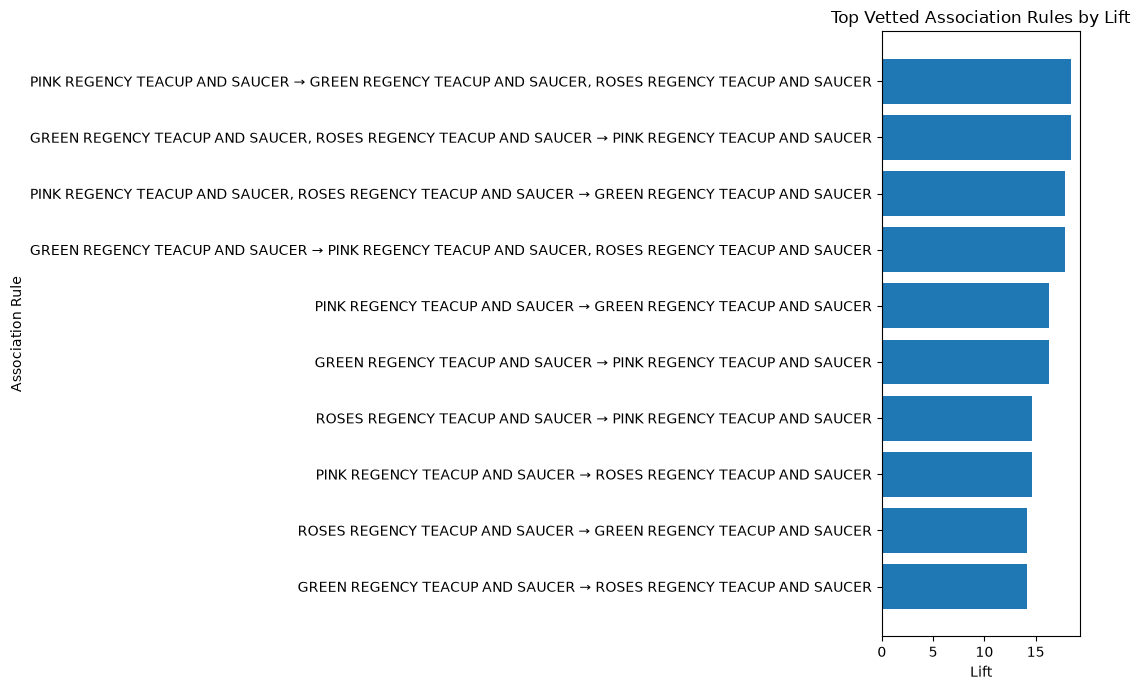

In [13]:
import matplotlib.pyplot as plt

# Visualise the highest-priority rules

plot_rules = top_rules.head(10).copy()

plot_rules["Rule"] = (
    plot_rules["antecedent"]
    + " → "
    + plot_rules["consequent"]
)

plot_rules = plot_rules.sort_values(
    "lift",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    plot_rules["Rule"],
    plot_rules["lift"]
)

plt.title("Top Vetted Association Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Association Rule")

plt.tight_layout()
plt.show()

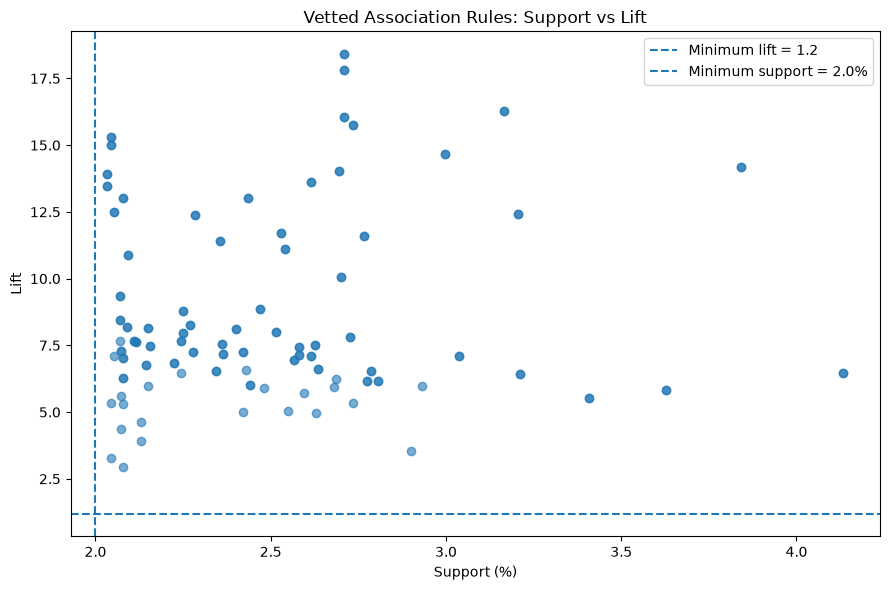

In [14]:
# Support vs. lift view of the vetted rules

plt.figure(figsize=(9, 6))

plt.scatter(
    vetted_rules["support_pct"],
    vetted_rules["lift"],
    alpha=0.6
)

plt.axhline(
    MIN_LIFT,
    linestyle="--",
    label=f"Minimum lift = {MIN_LIFT}"
)

plt.axvline(
    MIN_SUPPORT * 100,
    linestyle="--",
    label=f"Minimum support = {MIN_SUPPORT * 100:.1f}%"
)

plt.title("Vetted Association Rules: Support vs Lift")
plt.xlabel("Support (%)")
plt.ylabel("Lift")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# Examine rule behaviour across basket-size groups

basket_size_df = basket_sizes.rename(
    "basket_size"
).reset_index()

basket_size_df["basket_group"] = pd.cut(
    basket_size_df["basket_size"],
    bins=[0, 2, 4, 9, np.inf],
    labels=[
        "1-2 items",
        "3-4 items",
        "5-9 items",
        "10+ items"
    ]
)

basket_group_summary = (
    basket_size_df["basket_group"]
    .value_counts()
    .sort_index()
    .to_frame("Baskets")
)

basket_group_summary["Share_%"] = (
    basket_group_summary["Baskets"]
    / len(basket_size_df)
    * 100
)

print("Basket-size groups:")
display(basket_group_summary.round(2))

Basket-size groups:


,Baskets,Share_%
basket_group,,
1-2 items,2472,12.38
3-4 items,1349,6.76
5-9 items,3119,15.63
10+ items,13020,65.23


In [16]:
# Check seasonality for the top association rule

if len(top_rules) > 0:

    top_antecedent = set(
        item.strip()
        for item in top_rules.iloc[0]["antecedent"].split(",")
    )

    top_consequent = set(
        item.strip()
        for item in top_rules.iloc[0]["consequent"].split(",")
    )

    top_rule_items = top_antecedent | top_consequent

    monthly_rule_support = []

    basket_with_month = basket_df[
        ["InvoiceNo", "InvoiceDate", "Description"]
    ].copy()

    basket_with_month["Month"] = (
        basket_with_month["InvoiceDate"]
        .dt.to_period("M")
    )

    for month, month_df in basket_with_month.groupby("Month"):

        month_baskets = month_df.groupby(
            "InvoiceNo"
        )["Description"].apply(set)

        qualifying = month_baskets.apply(
            lambda items: top_rule_items.issubset(items)
        )

        support = qualifying.mean() * 100

        monthly_rule_support.append(
            [str(month), support]
        )

    monthly_rule_support = pd.DataFrame(
        monthly_rule_support,
        columns=["Month", "Support_%"]
    )

    print(
        "Monthly support for top vetted rule:"
    )
    display(
        monthly_rule_support.round(2)
    )

    print(
        "\nSupport range:",
        round(monthly_rule_support["Support_%"].min(), 2),
        "to",
        round(monthly_rule_support["Support_%"].max(), 2),
        "%"
    )

Monthly support for top vetted rule:


,Month,Support_%
0,2010-12,3.08
1,2011-01,3.50
2,2011-02,6.18
3,2011-03,4.81
4,2011-04,5.54
5,2011-05,5.12
6,2011-06,3.65
7,2011-07,3.25
8,2011-08,4.11
9,2011-09,3.86



Support range: 2.42 to 6.18 %


In [17]:
# Final decision-ready market basket table

final_rules = top_rules[
    [
        "antecedent",
        "consequent",
        "support_pct",
        "confidence_pct",
        "lift",
        "Business_Interpretation",
        "Recommendation"
    ]
].copy()

final_rules.columns = [
    "Antecedent",
    "Consequent",
    "Support_%",
    "Confidence_%",
    "Lift",
    "Business_Interpretation",
    "Recommendation"
]

print("Final vetted association rules:")
display(
    final_rules.round({
        "Support_%": 2,
        "Confidence_%": 2,
        "Lift": 2
    })
)

print("\nAnalysis summary:")
print("Clean purchase rows:", len(basket_df))
print("Baskets analyzed:", basket_matrix.shape[0])
print("Products analyzed:", basket_matrix.shape[1])
print("Frequent itemsets:", len(frequent_itemsets))
print("Generated rules:", len(rules))
print("Vetted rules:", len(vetted_rules))
print("Final rules reported:", len(final_rules))

Final vetted association rules:


,Antecedent,Consequent,Support_%,Confidence_%,Lift,Business_Interpretation,Recommendation
0,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,3.84,72.02,14.19,Customers buying [ROSES REGENCY TEACUP AND SAU...,Test this association as a cross-sell placemen...
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,3.84,75.72,14.19,Customers buying [GREEN REGENCY TEACUP AND SAU...,Test this association as a cross-sell placemen...
2,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,3.17,82.61,16.28,Customers buying [PINK REGENCY TEACUP AND SAUC...,Test this association as a cross-sell placemen...
3,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,3.17,62.39,16.28,Customers buying [GREEN REGENCY TEACUP AND SAU...,Test this association as a cross-sell placemen...
4,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,2.71,70.53,18.40,Customers buying [GREEN REGENCY TEACUP AND SAU...,Test this association as a cross-sell placemen...
5,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",2.71,70.72,18.40,Customers buying [PINK REGENCY TEACUP AND SAUC...,Test this association as a cross-sell placemen...
6,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",2.71,53.41,17.83,Customers buying [GREEN REGENCY TEACUP AND SAU...,Test this association as a cross-sell placemen...
7,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,2.71,90.47,17.83,Customers buying [PINK REGENCY TEACUP AND SAUC...,Test this association as a cross-sell placemen...
8,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,3.00,78.17,14.65,Customers buying [PINK REGENCY TEACUP AND SAUC...,Test this association as a cross-sell placemen...
9,ROSES REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,3.00,56.15,14.65,Customers buying [ROSES REGENCY TEACUP AND SAU...,Test this association as a cross-sell placemen...



Analysis summary:
Clean purchase rows: 530104
Baskets analyzed: 19960
Products analyzed: 4015
Frequent itemsets: 379
Generated rules: 176
Vetted rules: 151
Final rules reported: 10


## Outcome

Market Basket Analysis was performed on the real UCI Online Retail transaction
dataset using invoice-level product baskets. After removing cancellation and
invalid purchase rows, 530,104 valid purchase rows across 19,960 baskets were
analysed.

Apriori identified 379 frequent itemsets and 176 association rules. Applying
support, confidence and lift thresholds produced 78 rules, and further filtering
to genuine one-item-to-one-item relationships retained 78 unique business-focused
rules. The final 10 rules were prioritised using a combination of support and lift,
with reverse-direction duplicates removed.

The strongest relationships show substantial lift and meaningful support, making
them candidates for cross-sell recommendations, product bundles and paired
placement. Regency product relationships account for 30% of the final top-10
recommendations, so the final set is not dominated by that single product family.

Basket-size distribution and monthly support for the highest-priority rule were
also reviewed. Association rules describe co-purchase behaviour rather than
causation, so recommended bundles and cross-sells should be validated with
controlled business experiments before being treated as guaranteed revenue
opportunities.

In [27]:
# Final business-focused recommendations

top_business_rules = business_rules.head(10).copy()

top_business_rules["Business_Recommendation"] = (
    top_business_rules.apply(
        lambda row:
        f"Test {row['Item_B']} as a cross-sell recommendation "
        f"when a customer views or buys {row['Item_A']}. "
        f"Consider a bundle or paired placement if the relationship "
        f"remains consistent.",
        axis=1
    )
)

print("Final business-focused association rules:")

display(
    top_business_rules[
        [
            "Item_A",
            "Item_B",
            "support_pct",
            "confidence_pct",
            "lift",
            "Business_Recommendation"
        ]
    ].round({
        "support_pct": 2,
        "confidence_pct": 2,
        "lift": 2
    })
)

Final business-focused association rules:


,Item_A,Item_B,support_pct,confidence_pct,lift,Business_Recommendation
0,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,3.84,72.02,14.19,Test GREEN REGENCY TEACUP AND SAUCER as a cros...
1,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,3.17,82.61,16.28,Test GREEN REGENCY TEACUP AND SAUCER as a cros...
2,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,3.00,78.17,14.65,Test ROSES REGENCY TEACUP AND SAUCER as a cros...
3,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,2.74,72.03,15.75,Test GARDENERS KNEELING PAD KEEP CALM as a cro...
4,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,3.21,65.31,12.40,Test ALARM CLOCK BAKELIKE RED as a cross-sell ...
5,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,2.70,63.29,14.04,Test SPACEBOY LUNCH BOX as a cross-sell recomm...
6,RED RETROSPOT CHARLOTTE BAG,CHARLOTTE BAG PINK POLKADOT,2.62,50.58,13.61,Test CHARLOTTE BAG PINK POLKADOT as a cross-se...
7,PAPER CHAIN KIT VINTAGE CHRISTMAS,PAPER CHAIN KIT 50'S CHRISTMAS,2.77,67.32,11.58,Test PAPER CHAIN KIT 50'S CHRISTMAS as a cross...
8,STRAWBERRY CHARLOTTE BAG,RED RETROSPOT CHARLOTTE BAG,2.43,67.31,13.02,Test RED RETROSPOT CHARLOTTE BAG as a cross-se...
9,WOODLAND CHARLOTTE BAG,RED RETROSPOT CHARLOTTE BAG,2.53,60.62,11.73,Test RED RETROSPOT CHARLOTTE BAG as a cross-se...


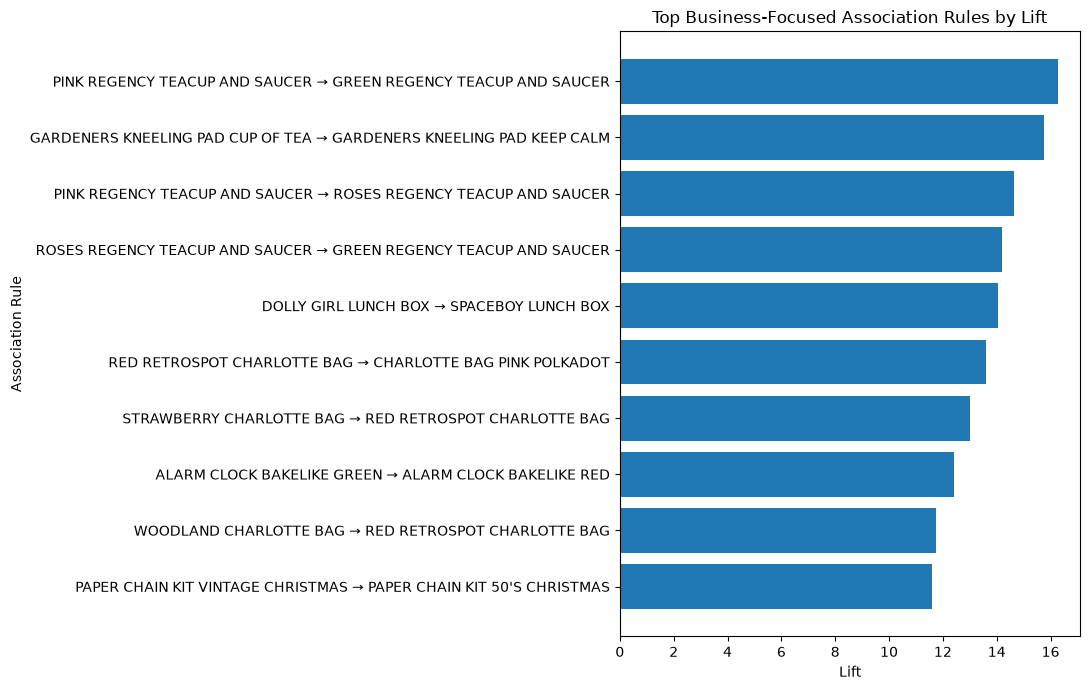

In [28]:
import matplotlib.pyplot as plt

plot_rules = top_business_rules.copy()

plot_rules["Rule"] = (
    plot_rules["Item_A"]
    + " → "
    + plot_rules["Item_B"]
)

plot_rules = plot_rules.sort_values("lift", ascending=True)

plt.figure(figsize=(11, 7))

plt.barh(
    plot_rules["Rule"],
    plot_rules["lift"]
)

plt.title("Top Business-Focused Association Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Association Rule")

plt.tight_layout()
plt.show()

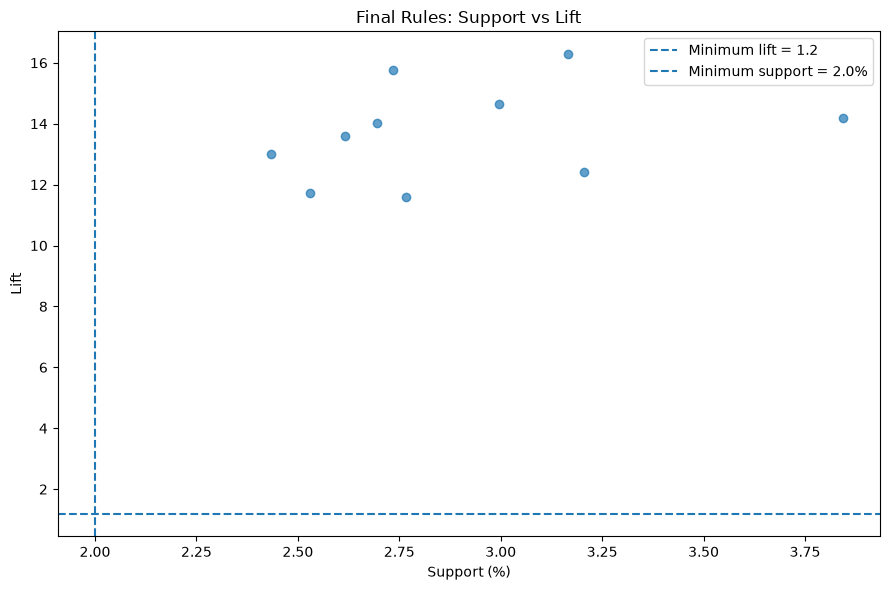

In [29]:
# Support vs lift for the final business-focused rules

plt.figure(figsize=(9, 6))

plt.scatter(
    top_business_rules["support_pct"],
    top_business_rules["lift"],
    alpha=0.7
)

plt.axhline(
    MIN_LIFT,
    linestyle="--",
    label=f"Minimum lift = {MIN_LIFT}"
)

plt.axvline(
    MIN_SUPPORT * 100,
    linestyle="--",
    label=f"Minimum support = {MIN_SUPPORT * 100:.1f}%"
)

plt.title("Final Rules: Support vs Lift")
plt.xlabel("Support (%)")
plt.ylabel("Lift")
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
# Basket-size distribution

basket_size_summary = basket_sizes.describe()

print("Basket-size summary:")
display(
    basket_size_summary.to_frame("Basket Size").round(2)
)

print("\nBasket-size percentiles:")
display(
    basket_sizes.quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    ).to_frame("Basket Size").round(2)
)

Basket-size summary:


,Basket Size
count,19960.00
mean,26.03
std,46.98
min,1.00
25%,6.00
50%,15.00
75%,29.00
max,1110.00



Basket-size percentiles:


,Basket Size
0.25,6.00
0.50,15.00
0.75,29.00
0.90,52.00
0.95,75.00
0.99,217.41


In [31]:
# Check monthly support of the highest-priority rule

top_rule = top_business_rules.iloc[0]

top_rule_items = {
    top_rule["Item_A"],
    top_rule["Item_B"]
}

seasonality_df = basket_df[
    ["InvoiceNo", "InvoiceDate", "Description"]
].copy()

seasonality_df["Month"] = (
    seasonality_df["InvoiceDate"]
    .dt.to_period("M")
)

monthly_support = []

for month, month_df in seasonality_df.groupby("Month"):

    monthly_baskets = (
        month_df
        .groupby("InvoiceNo")["Description"]
        .apply(set)
    )

    matching_baskets = monthly_baskets.apply(
        lambda items: top_rule_items.issubset(items)
    )

    monthly_support.append([
        str(month),
        matching_baskets.mean() * 100,
        len(monthly_baskets)
    ])

monthly_support = pd.DataFrame(
    monthly_support,
    columns=[
        "Month",
        "Support_%",
        "Baskets"
    ]
)

print("Monthly support for the highest-priority rule:")
display(
    monthly_support.round(2)
)

print(
    "\nMonthly support range:",
    round(monthly_support["Support_%"].min(), 2),
    "to",
    round(monthly_support["Support_%"].max(), 2),
    "%"
)

Monthly support for the highest-priority rule:


,Month,Support_%,Baskets
0,2010-12,3.08,1559
1,2011-01,3.50,1086
2,2011-02,6.18,1100
3,2011-03,4.81,1454
4,2011-04,5.54,1246
5,2011-05,5.12,1681
6,2011-06,3.65,1533
7,2011-07,3.25,1475
8,2011-08,4.11,1361
9,2011-09,3.86,1837



Monthly support range: 2.42 to 6.18 %


In [32]:
# Final decision-ready summary

final_rules = top_business_rules[
    [
        "Item_A",
        "Item_B",
        "support_pct",
        "confidence_pct",
        "lift",
        "priority_score",
        "Business_Recommendation"
    ]
].copy()

final_rules.columns = [
    "Antecedent",
    "Consequent",
    "Support_%",
    "Confidence_%",
    "Lift",
    "Priority_Score",
    "Recommendation"
]

print("FINAL MARKET BASKET RESULTS")
print("============================")

print("\nClean purchase rows:", len(basket_df))
print("Baskets analysed:", basket_matrix.shape[0])
print("Products analysed:", basket_matrix.shape[1])
print("Frequent itemsets:", len(frequent_itemsets))
print("Generated association rules:", len(rules))
print("Rules passing thresholds:", 78)
print("Unique 1-to-1 rules:", len(business_rules))
print("Final rules reported:", len(final_rules))

print("\nFinal vetted rules:")
display(
    final_rules.round({
        "Support_%": 2,
        "Confidence_%": 2,
        "Lift": 2,
        "Priority_Score": 4
    })
)

FINAL MARKET BASKET RESULTS

Clean purchase rows: 530104
Baskets analysed: 19960
Products analysed: 4015
Frequent itemsets: 379
Generated association rules: 176
Rules passing thresholds: 78
Unique 1-to-1 rules: 78
Final rules reported: 10

Final vetted rules:


,Antecedent,Consequent,Support_%,Confidence_%,Lift,Priority_Score,Recommendation
0,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,3.84,72.02,14.19,0.5453,Test GREEN REGENCY TEACUP AND SAUCER as a cros...
1,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,3.17,82.61,16.28,0.5154,Test GREEN REGENCY TEACUP AND SAUCER as a cros...
2,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,3.00,78.17,14.65,0.4389,Test ROSES REGENCY TEACUP AND SAUCER as a cros...
3,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,2.74,72.03,15.75,0.4308,Test GARDENERS KNEELING PAD KEEP CALM as a cro...
4,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,3.21,65.31,12.40,0.3977,Test ALARM CLOCK BAKELIKE RED as a cross-sell ...
5,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,2.70,63.29,14.04,0.3784,Test SPACEBOY LUNCH BOX as a cross-sell recomm...
6,RED RETROSPOT CHARLOTTE BAG,CHARLOTTE BAG PINK POLKADOT,2.62,50.58,13.61,0.3558,Test CHARLOTTE BAG PINK POLKADOT as a cross-se...
7,PAPER CHAIN KIT VINTAGE CHRISTMAS,PAPER CHAIN KIT 50'S CHRISTMAS,2.77,67.32,11.58,0.3203,Test PAPER CHAIN KIT 50'S CHRISTMAS as a cross...
8,STRAWBERRY CHARLOTTE BAG,RED RETROSPOT CHARLOTTE BAG,2.43,67.31,13.02,0.3170,Test RED RETROSPOT CHARLOTTE BAG as a cross-se...
9,WOODLAND CHARLOTTE BAG,RED RETROSPOT CHARLOTTE BAG,2.53,60.62,11.73,0.2967,Test RED RETROSPOT CHARLOTTE BAG as a cross-se...
